In [9]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END


In [10]:
class AgentState(TypedDict):
    name: str
    age: int
    skills: List[str]
    result: str


In [11]:
def first_node(state: AgentState):
    """this is the first node"""
    state['result'] = f"{state['name']}, welcome to the system."
    return state


def second_node(state: AgentState):
    """This is the second node"""
    skills = ",".join(state['skills'])
    state['result'] = state['result'] + f"You have skills in {skills}."
    return state


def third_node(state: AgentState):
    """this is the third node"""
    state['result'] = state['result'] + f"You are {state['age']} years old"
    return state

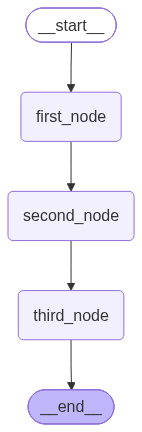

In [12]:
graph = StateGraph(AgentState)
graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)
graph.add_node("third_node", third_node)

graph.add_edge(START, "first_node")
graph.add_edge("first_node", "second_node")
graph.add_edge("second_node", "third_node")
graph.add_edge("third_node", END)
bot = graph.compile()
bot

In [13]:
response = bot.invoke({"name": "Minhaz Uddin","age":29,"skills":["Java","Html"]})
response


{'name': 'Minhaz Uddin',
 'age': 29,
 'skills': ['Java', 'Html'],
 'result': 'Minhaz Uddin, welcome to the system.You have skills in Java,Html.You are 29 years old'}